In [1]:
import numpy as np
def N_mean(fasta_file):
    f = open(fasta_file, 'r')
    N_dict = {}
    for line in f:
        if line[0] == '>':
            seq_ID = line[line.find('>')+1:].rstrip()
        else:
            len_seq = len(line.rstrip())
            N_number = line.count('N')
            N_mean = float(N_number) / len_seq
            raw = [len_seq, N_number, N_mean]
            N_dict[seq_ID] = raw
    f.close()
    return N_dict
def retire_amb_seqs(fasta_file, N_mean_min = 0.1):
    N_data = N_mean(fasta_file)
    f = open(fasta_file, 'r')
    out_name = fasta_file[:fasta_file.find('.fa')] + '_no_amb_seqs.fasta'
    f_out = open(out_name, 'w')
    for line in f:
        if line[0] == '>':
            seq_key = line[line.find('>')+1:].rstrip()
        elif N_data[seq_key][2] <= N_mean_min:
            new_line = '>' + seq_key + '\n'
            f_out.write(new_line)
            f_out.write(line)
        else:
            continue
    f.close()
    f_out.close()
def longest_seq(fasta_file):
    f = open(fasta_file, 'r')
    long_seq = 0
    for line in f:
        if line[0] != '>' and len(line.rstrip()) > long_seq:
            long_seq = len(line.rstrip())
    f.close()
    return long_seq
def N_positions_frequency(fasta_file):
    seqs = change_Seq_to_list(fasta_file)
    long_seq = longest_seq(fasta_file)
    N_count = []
    analized_seq = []
    N_freq = []
    for seq in seqs:
        if len(seq) < long_seq:
            for i in range(long_seq-len(seq)):
                seq.append('*')
    seqs = np.array(seqs)
    traspose_seqs = seqs.transpose()
    for line in traspose_seqs:
        N_count.append(list(line).count('N'))
        analized_seq.append((len(line) - list(line).count('*')))
        N_freq.append(float(list(line).count('N')/(len(line) - list(line).count('*'))))
    return [N_count, analized_seq, N_freq]
def change_Seq_to_list(fasta_file):
    f = open(fasta_file,'r')
    seqs = []
    for line in f:
        if line[0] != '>':
            seqs.append(list(line.rstrip()))
    return seqs

In [ ]:
retire_amb_seqs('Latrodectushesperus_no_clstrd_with_N.fasta')
retire_amb_seqs('Leucaugevenusta_no_clstrd_with_N.fasta')
retire_amb_seqs('Nephilaantipodiana_no_clstrd_with_N.fasta')
retire_amb_seqs('Parasteatodatepidariorum_no_clstrd_with_N.fasta')
retire_amb_seqs('Steatodagrossa_no_clstrd_with_N.fasta')

In [2]:
Latrodectushesperus_N_freq = N_positions_frequency('Latrodectushesperus_no_clstrd_with_N_no_amb_seqs.fasta')
Leucaugevenusta_N_freq = N_positions_frequency('Leucaugevenusta_no_clstrd_with_N_no_amb_seqs.fasta')
Nephilaantipodiana_N_freq = N_positions_frequency('Nephilaantipodiana_no_clstrd_with_N_no_amb_seqs.fasta')
Parasteatodatepidariorum_N_freq = N_positions_frequency('Parasteatodatepidariorum_no_clstrd_with_N_no_amb_seqs.fasta')
Steatodagrossa_N_freq = N_positions_frequency('Steatodagrossa_no_clstrd_with_N_no_amb_seqs.fasta')

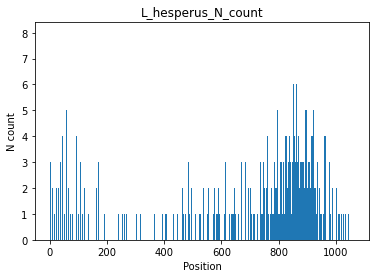

In [34]:
import matplotlib.pyplot as plt

plt.bar(list(range(len(Latrodectushesperus_N_freq[0]))),Latrodectushesperus_N_freq[0])
plt.xlabel('Position')
plt.ylabel('N count')
plt.title('L_hesperus_N_count')
plt.savefig('L_hesperus_N_number.pdf')
plt.show()



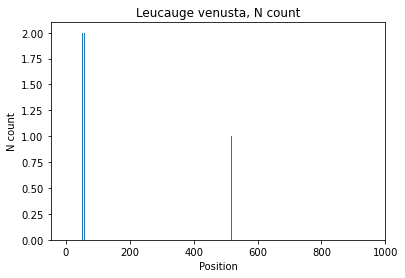

In [35]:

plt.bar(list(range(len(Leucaugevenusta_N_freq[0]))),Leucaugevenusta_N_freq[0])
plt.xlabel('Position')
plt.ylabel('N count')
plt.title('Leucauge venusta, N count')
plt.savefig('Leucauge_venusta_Ncount.pdf')
plt.show()
    

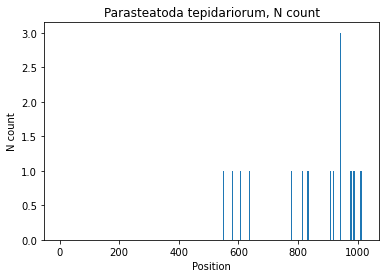

In [36]:
plt.bar(list(range(len(Parasteatodatepidariorum_N_freq[0]))),Parasteatodatepidariorum_N_freq[0])
plt.xlabel('Position')
plt.ylabel('N count')
plt.title('Parasteatoda tepidariorum, N count')
plt.savefig('Parasteatoda_tepidariorum_Ncount.pdf')
plt.show()                                                                                         
                                                                                        

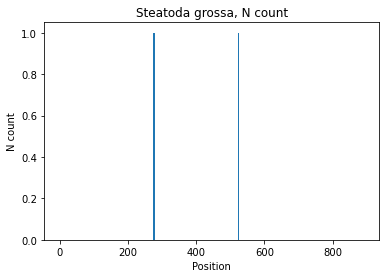

In [37]:
plt.bar(list(range(len(Steatodagrossa_N_freq[0]))),Steatodagrossa_N_freq[0])
plt.xlabel('Position')
plt.ylabel('N count')
plt.title('Steatoda grossa, N count')
plt.savefig('Steatoda_grossa_Ncount.pdf')
plt.show()